# Q* Learning with Taxi 🚕

In this Notebook, we'll implement an agent <b>that plays Taxi.</b>

[Link to the environment](https://gymnasium.farama.org/environments/toy_text/taxi/)

The goal of this game is <b>to pick up the passenger at one location and drop them off at another.</b>
The taxi drives around a 5x5 grid; it gets a small penalty for every move (so it learns to be quick),
a big reward for a correct drop-off, and a big penalty for trying to pick up / drop off in the wrong place.

Same recipe as the *FrozenLake* notebook, just a bigger world: Taxi is **deterministic** (no slippery ice),
but it has **500 states**, so the agent needs more practice to fill in its Q-table.

## Step -1: Install the dependencies on Google Colab

In [1]:
import numpy as np
# gymnasium gives us the Taxi game. The [toy-text] extra pulls in pygame, which we need later
# to draw the little taxi for the video replay.
!pip install "gymnasium[toy-text]" > /dev/null 2>&1

## Step 0: Import the dependencies 📚
We use 3 libraries:
- `Numpy` for our Qtable
- `Gymnasium` for our Taxi Environment
- `Random` to generate random numbers (for exploration)

In [2]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt

## Step 1: Create the environment 🎮
- Here we'll create the Taxi environment.
- Gymnasium is a library <b>composed of many environments that we can use to train our agents.</b>
- In our case we choose to use Taxi.

In [3]:
# Newer gymnasium versions renamed Taxi-v3 -> Taxi-v4 (same game). This helper just grabs
# whichever one is installed, so the notebook runs both on Colab and locally.
def make_taxi(render_mode=None):
    last_error = None
    for version in ("Taxi-v3", "Taxi-v4"):
        try:
            return gym.make(version, render_mode=render_mode)
        except Exception as e:        # this version isn't available -> try the next one
            last_error = e
    raise last_error

env = make_taxi(render_mode="rgb_array")
print("Using:", env.spec.id)

# The 5x5 map. R, G, Y, B are the 4 possible pickup / drop-off spots.
#         col→   0   1   2   3   4
#              +---------------------+
#   row 0      | R :   | :   :   : G |
#   row 1      |   :   | :   :   :   |
#   row 2      |   :   :   :   :   : |
#   row 3      |   |   : | :   |   : |
#   row 4      | Y |   : | : B :   : |
#              +---------------------+
#
# A "state" packs 3 things into a single number 0..499:
#   - where the taxi is        (25 squares)
#   - where the passenger is   (at R/G/Y/B, or already inside the taxi -> 5 options)
#   - where they want to go    (R/G/Y/B -> 4 options)
#   25 * 5 * 4 = 500 states.
#
# The 6 actions the taxi can take:
#   0 = move South ↓   1 = move North ↑   2 = move East →   3 = move West ←
#   4 = Pickup passenger        5 = Drop-off passenger
#
# The rewards (this is what the agent is chasing):
#   -1  for every step           (so it learns the SHORT route)
#   +20 for a correct drop-off   (the actual goal)
#   -10 for an illegal pickup/drop-off (don't do that)

Using: Taxi-v4


/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment Taxi-v3 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


## Step 2: Create the Q-table and initialize it 🗄️
- Now, we'll create our Q-table. To know how many rows (states) and columns (actions) we need,
  we read `env.action_space.n` and `env.observation_space.n` straight from the environment.

In [13]:
action_size = env.action_space.n
state_size = env.observation_space.n

print(f"Action space is {action_size}; State_space is {state_size}\n")

Action space is 6; State_space is 500



In [5]:
# Create our Q table with state_size rows and action_size columns.
# Every value starts at 0 -> the agent begins knowing nothing about any state.
qtable = np.zeros((state_size, action_size))
print(qtable.shape)
# Each row is one state and holds one Q-value per action.
# for example qtable[328] = [ -2.31, -1.95, -2.08, -1.84, -10.4,  7.97 ]
#                              South   North   East   West  Pickup  Dropoff
# -> the highest value (7.97) is "Dropoff", so in state 328 the best move is to drop the passenger.

(500, 6)


## Step 3: Create the hyperparameters ⚙️
- Here, we'll specify the hyperparameters.
- Taxi has many more states than FrozenLake, so we train for more episodes and let exploration fade slowly.

In [6]:
total_episodes = 25000       # How many full games the agent gets to practice on.
learning_rate = 0.7          # alpha: how much we update our Q-values based on new information.
max_steps = 200              # How many steps allowed per game before we cut it off (Taxi also auto-stops at 200).
gamma = 0.95                 # discount factor (how much we value future rewards vs reward right now).

# Exploration parameters (epsilon = how often we choose a RANDOM action instead of the best known one)
epsilon = 1.0                 # Exploration rate (start by exploring everything, we know nothing yet)
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability (keep a tiny 1% curiosity forever)
decay_rate = 0.0005           # how fast that curiosity fades as the agent gets smarter

## Step 4: The Q learning algorithm 🧠
- Now we implement the Q learning algorithm. For every step we nudge `Q(s,a)` towards the reward we
  just got plus the best value we can reach next:

  ![alt text](http://simoninithomas.com/drlc/Qlearning//qtable_algo.png)

Score over time: -9.87252
Score over last 1000 games: 7.477


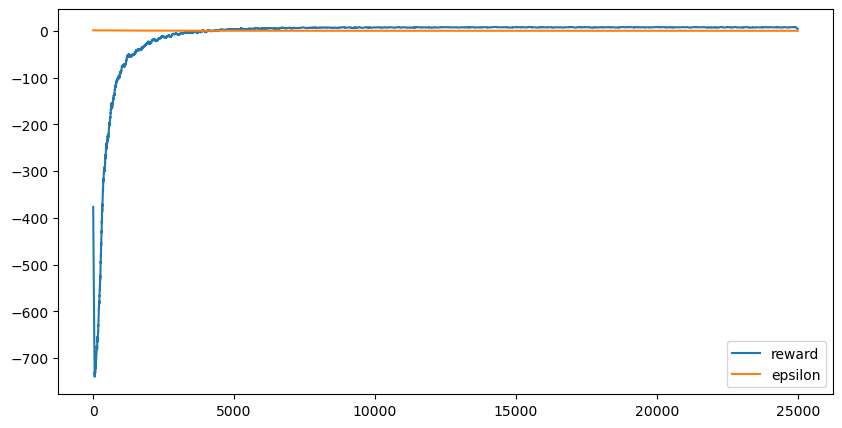

In [7]:
# List of rewards (and epsilons) so we can plot the learning curve afterwards
rewards = []
epsilons = []

for episode in range(total_episodes):
    # Reset the environment - Gymnasium returns (state, info)
    state, info = env.reset()
    step = 0
    done = False
    total_rewards = 0

    for step in range(max_steps):
        # Choose an action a in the current world state (s): explore or exploit?
        exp_exp_tradeoff = random.uniform(0, 1)

        if exp_exp_tradeoff > epsilon:
            action = np.argmax(qtable[state, :])   # exploit: take the best action we know
        else:
            action = env.action_space.sample()     # explore: try a random action

        # Take action - Gymnasium returns 5 values
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Update Q(s,a)
        qtable[state, action] = qtable[state, action] + learning_rate * (
            reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action]
        )   # (reward + gamma*max(...)) - qtable[state, action] is the correction (gap between belief and reality)

        total_rewards += reward
        state = new_state

        if done:
            break

    # Reduce epsilon (explore less and less as the agent gets smarter)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    epsilons.append(epsilon)
    rewards.append(total_rewards)   # each Q-value is the estimated sum of all future (discounted) rewards from
                                    # that state, assuming optimal play.
                                    # Q*(s, a) = r  +  γ · max_a' Q*(s', a')   BELLMAN OPTIMALITY EQUATION

print("Score over time: " + str(sum(rewards) / total_episodes))
print("Score over last 1000 games: " + str(sum(rewards[-1000:]) / 1000))

# Plotting results
plt.figure(figsize=(10, 5))
averagingN = 100
plt.plot(range(total_episodes), np.convolve(rewards, np.ones(averagingN)/averagingN, mode='same'), label="reward")
plt.plot(range(total_episodes), epsilons, label='epsilon')
plt.legend(loc="lower right")
plt.show()

## Step 5: Use our Q-table to play Taxi ! 👾
- After training, our Q-table can be used as a "cheatsheet" to play Taxi.
- By running these cells you can see (and record a video of) our agent playing Taxi.
- We follow the exact same recording approach as the FrozenLake notebook.

In [8]:
# install for rendering the game (and recording a video on Colab)
#remove " > /dev/null 2>&1" to see what is going on under the hood
!pip install --force-reinstall pygame gymnasium > /dev/null 2>&1
!pip install pyvirtualdisplay > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1

In [9]:
!apt-get update > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1
!pip install --upgrade setuptools > /dev/null 2>&1
!pip install ez_setup > /dev/null 2>&1
!apt-get install -y xvfb # Install the Xvfb server

zsh:1: command not found: apt-get


In [10]:
import gymnasium as gym
%matplotlib inline
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

In [11]:
import os
os.environ['SDL_VIDEODRIVER'] = 'dummy'   # let pygame draw without a real screen (needed on Colab)
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

FileNotFoundError: [Errno 2] No such file or directory: 'Xvfb'

In [ ]:
"""
Utility functions to enable video recording of gymnasium environment and displaying it
"""

def show_video():
    # Search specifically in the 'video' folder for mp4 files
    mp4list = glob.glob('./video/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[-1]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        ipythondisplay.display(HTML(data="""<video alt="test" autoplay
                    loop controls style="height: 400px;">
                    <source src="data:video/mp4;base64,{0}" type="video/mp4" />
                 </video>""".format(encoded.decode('ascii'))))
    else:
        print("Could not find video in ./video/ folder")

def wrap_env(env):
    # Force RecordVideo to record all episodes (episode_trigger returns True for all)
    env = gym.wrappers.RecordVideo(env, video_folder="./video", episode_trigger=lambda x: True, disable_logger=True)
    return env

In [ ]:
# Re-initialize the environment with the wrapper
env = make_taxi(render_mode="rgb_array")
env = wrap_env(env)

In [ ]:
# make the inference and record the video

state, info = env.reset()
step = 0
done = False

# nice names just so the printout is readable
action_names = {0: "South ↓", 1: "North ↑", 2: "East →", 3: "West ←", 4: "Pickup", 5: "Drop-off"}

for step in range(max_steps):

    # Take the action that has the maximum expected future reward (no more exploring, pure cheatsheet)
    action = np.argmax(qtable[state, :])

    # RecordVideo automatically captures frames when env.step is called
    new_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    if done:
        if terminated:                      # in Taxi, an episode only "terminates" on a correct drop-off
            print("Passenger delivered 🏆")
        else:                               # truncated -> we hit the 200-step limit without finishing
            print("Ran out of time ☠️")
        print("Number of steps", step)
        break
    state = new_state

env.close()

In [ ]:
show_video()

## Step 6: Evaluate the trained agent 📊  (bonus)
One game can get lucky. Let's play 100 games greedily (no exploration) and report the averages.
A well-trained Taxi agent scores around **+8 reward in ~13 steps with a 100% success rate**.

In [ ]:
n_eval = 100
ev_rewards, ev_steps, successes = [], [], 0

for _ in range(n_eval):
    state, info = env.reset()
    total = 0
    for step in range(max_steps):
        action = np.argmax(qtable[state, :])     # always exploit the cheatsheet
        state, reward, terminated, truncated, info = env.step(action)
        total += reward
        if terminated:                           # delivered the passenger correctly
            successes += 1
            break
        if truncated:                            # ran out of time
            break
    ev_rewards.append(total)
    ev_steps.append(step + 1)

print(f"Over {n_eval} games (greedy / no exploration):")
print(f"  average reward : {np.mean(ev_rewards):.2f}")
print(f"  average steps  : {np.mean(ev_steps):.1f}")
print(f"  success rate   : {successes}/{n_eval}")